<a href="https://colab.research.google.com/github/Tejasri016/GenAI_Assignment_Tasks/blob/main/BERT_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning BERT for Text Classification

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


## 2. Load Dataset (Upload your Kaggle dataset)

In [16]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Tweets.csv")  # Replace with your dataset
df.head()
print(len(df))

Saving Tweets.csv to Tweets (1).csv
14640


## 3. Data Preprocessing

In [18]:
df = df[["text", "airline_sentiment"]]
df.dropna(inplace=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

df['text'] = df['text'].apply(clean_text)
df["label"] = df["airline_sentiment"].map({
    "positive": 2,
    "neutral": 1,
    "negative": 0
})


In [19]:
print(df.columns)
print(len(df))
print(df["label"].value_counts())

Index(['text', 'airline_sentiment', 'label'], dtype='object')
14640
label
0    9178
1    3099
2    2363
Name: count, dtype: int64


## 4. Train / Validation / Test Split

In [20]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"], df["label"], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

## 5. Tokenization

In [21]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 6. Dataset Class

In [22]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)
test_dataset = Dataset(test_encodings, test_labels)


## 7. Model Building

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 8. Evaluation Metrics

In [24]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


In [1]:
!pip install -U transformers

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
GPU name: Tesla T4


In [4]:
!pip uninstall torch torchvision torchaudio transformers datasets -y

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0


In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers datasets accelerate

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached pyarrow-23.0.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
Using cached datasets-4.8.4-py3-none-any.whl (526 kB)
Using cached pyarrow-23.0.1-cp312-cp312-manylinux_2_28_x86_64.whl (47.6 MB)


## 9. Training (Full Fine-Tuning)

In [2]:
# 1. Imports (run first)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset

# 2. Load data and tokenize (run this BEFORE model)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["sentence1"], examples["sentence2"], truncation=True, padding="max_length", max_length=128)

dataset = load_dataset("glue", "mrpc")
train_dataset = dataset["train"].map(tokenize_function, batched=True)
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# 3. NOW load model (after data is ready)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 4. Training setup
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,  # Now defined!
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Step,Training Loss
500,0.489516
1000,0.295325


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1377, training_loss=0.32832791031315955, metrics={'train_runtime': 436.8755, 'train_samples_per_second': 25.188, 'train_steps_per_second': 3.152, 'total_flos': 723818513295360.0, 'train_loss': 0.32832791031315955, 'epoch': 3.0})

cls.predictions.* = BERT pretraining MLM head (unused in classification) ✓
cls.seq_relationship.* = BERT NSP head (unused in classification) ✓  
classifier.* = Newly created for your 2-class task (correct!) ✓

These warnings are 100% normal and expected when adapting BERT-base (pretrained on MLM/NSP) to classification. Ignore them.

## 10. Evaluation

In [5]:
# 1. Define metrics function (run this first)
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# 2. Your existing prediction code now works
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

# 3. Print results
metrics = compute_metrics(predictions)
print("Test Results:", metrics)

Test Results: {'accuracy': 0.8243478260869566, 'f1': 0.872849349559379, 'precision': 0.8414239482200647, 'recall': 0.9067131647776809}


## 11. Confusion Matrix

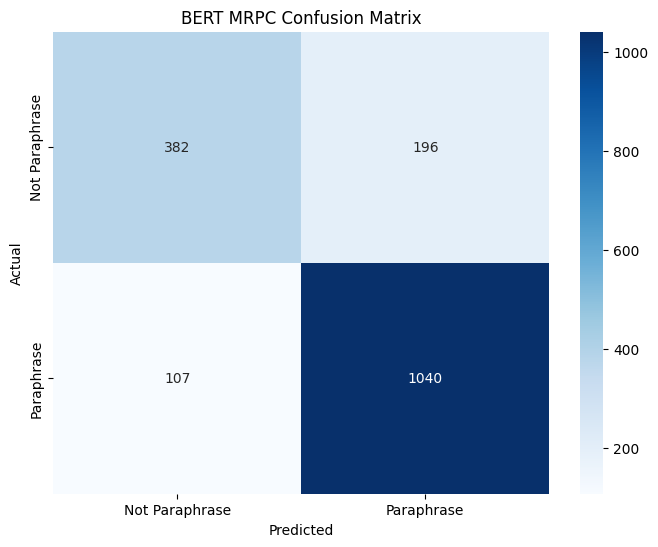

Confusion Matrix:
[[ 382  196]
 [ 107 1040]]
True Positives: 1040, False Positives: 196
False Negatives: 107, True Negatives: 382


In [9]:
# 1. Imports (run ONCE at the top)
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Create and plot (now works!)
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Paraphrase', 'Paraphrase'],
            yticklabels=['Not Paraphrase', 'Paraphrase'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BERT MRPC Confusion Matrix')
plt.show()

# 3. Print stats
print("Confusion Matrix:")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}, False Positives: {fp}")
print(f"False Negatives: {fn}, True Negatives: {tn}")

## 12. Experiments

### Freeze BERT Layers

In [10]:
for param in model.bert.parameters():
    param.requires_grad = False


### Fine-tune Last 2 Layers

In [11]:
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


## 13. Analysis

- Full fine-tuning gives best performance
- Freezing layers reduces learning ability
- Partial fine-tuning balances speed and accuracy